In [32]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

base_dir = Path("..") / "runs" / "hs_ws_runs"
run_dirs = sorted([p for p in base_dir.iterdir() if p.is_dir()])


def parse_run_meta(run_name):
    return {
        "hidden_size": int(re.search(r"_h(\d+)_", run_name).group(1)),
        "ws": float(re.search(r"_ws([\d.]+)_", run_name).group(1)),
    }


hidden_sizes = sorted({parse_run_meta(p.name)["hidden_size"] for p in run_dirs})
ws_values = sorted({parse_run_meta(p.name)["ws"] for p in run_dirs})
colors = {hs: plt.cm.tab10(i) for i, hs in enumerate(hidden_sizes)}
linestyles = dict(zip(ws_values, ["-", "--", ":"]))
run_dirs

[WindowsPath('../runs/hs_ws_runs/memory_network_h1024_ws1.0_id2606221443'),
 WindowsPath('../runs/hs_ws_runs/memory_network_h1024_ws1.5_id2606221443'),
 WindowsPath('../runs/hs_ws_runs/memory_network_h1024_ws2.25_id2606221443'),
 WindowsPath('../runs/hs_ws_runs/memory_network_h128_ws1.0_id2606221443'),
 WindowsPath('../runs/hs_ws_runs/memory_network_h128_ws1.5_id2606221443'),
 WindowsPath('../runs/hs_ws_runs/memory_network_h128_ws2.25_id2606221443'),
 WindowsPath('../runs/hs_ws_runs/memory_network_h256_ws1.0_id2606221443'),
 WindowsPath('../runs/hs_ws_runs/memory_network_h256_ws1.5_id2606221443'),
 WindowsPath('../runs/hs_ws_runs/memory_network_h256_ws2.25_id2606221443'),
 WindowsPath('../runs/hs_ws_runs/memory_network_h512_ws1.0_id2606221443'),
 WindowsPath('../runs/hs_ws_runs/memory_network_h512_ws1.5_id2606221443'),
 WindowsPath('../runs/hs_ws_runs/memory_network_h512_ws2.25_id2606221443'),
 WindowsPath('../runs/hs_ws_runs/memory_network_h64_ws1.0_id2606221443'),
 WindowsPath('../ru

In [33]:
def load_scalars(run_dir, tag):
    event_files = sorted(run_dir.glob('events.out.tfevents*'))
    if not event_files:
        return pd.DataFrame()

    event_file = event_files[0]
    ea = EventAccumulator(str(event_file), size_guidance={'scalars': 0})
    ea.Reload()
    scalars = ea.Scalars(tag)

    if not scalars:
        return pd.DataFrame()

    df = pd.DataFrame([{'step': s.step, 'value': s.value} for s in scalars])
    df['run'] = run_dir.name
    df['tag'] = tag
    return df

for tag in ['train/loss', 'valid/loss']:
    frames = []
    for run_dir in run_dirs:
        df = load_scalars(run_dir, tag)
        if not df.empty:
            frames.append(df)
    if frames:
        globals()[f"{tag.replace('/', '_')}_df"] = pd.concat(frames, ignore_index=True)

train_loss_df

,step,value,run,tag
0,15,0.241069,memory_network_h1024_ws1.0_id2606221443,train/loss
1,31,0.033156,memory_network_h1024_ws1.0_id2606221443,train/loss
2,47,0.031800,memory_network_h1024_ws1.0_id2606221443,train/loss
3,63,0.031529,memory_network_h1024_ws1.0_id2606221443,train/loss
4,79,0.031412,memory_network_h1024_ws1.0_id2606221443,train/loss
...,...,...,...,...
3429,5535,0.000578,memory_network_h64_ws2.25_id2606221443,train/loss
3430,5551,0.000578,memory_network_h64_ws2.25_id2606221443,train/loss
3431,5567,0.000581,memory_network_h64_ws2.25_id2606221443,train/loss
3432,5583,0.000580,memory_network_h64_ws2.25_id2606221443,train/loss


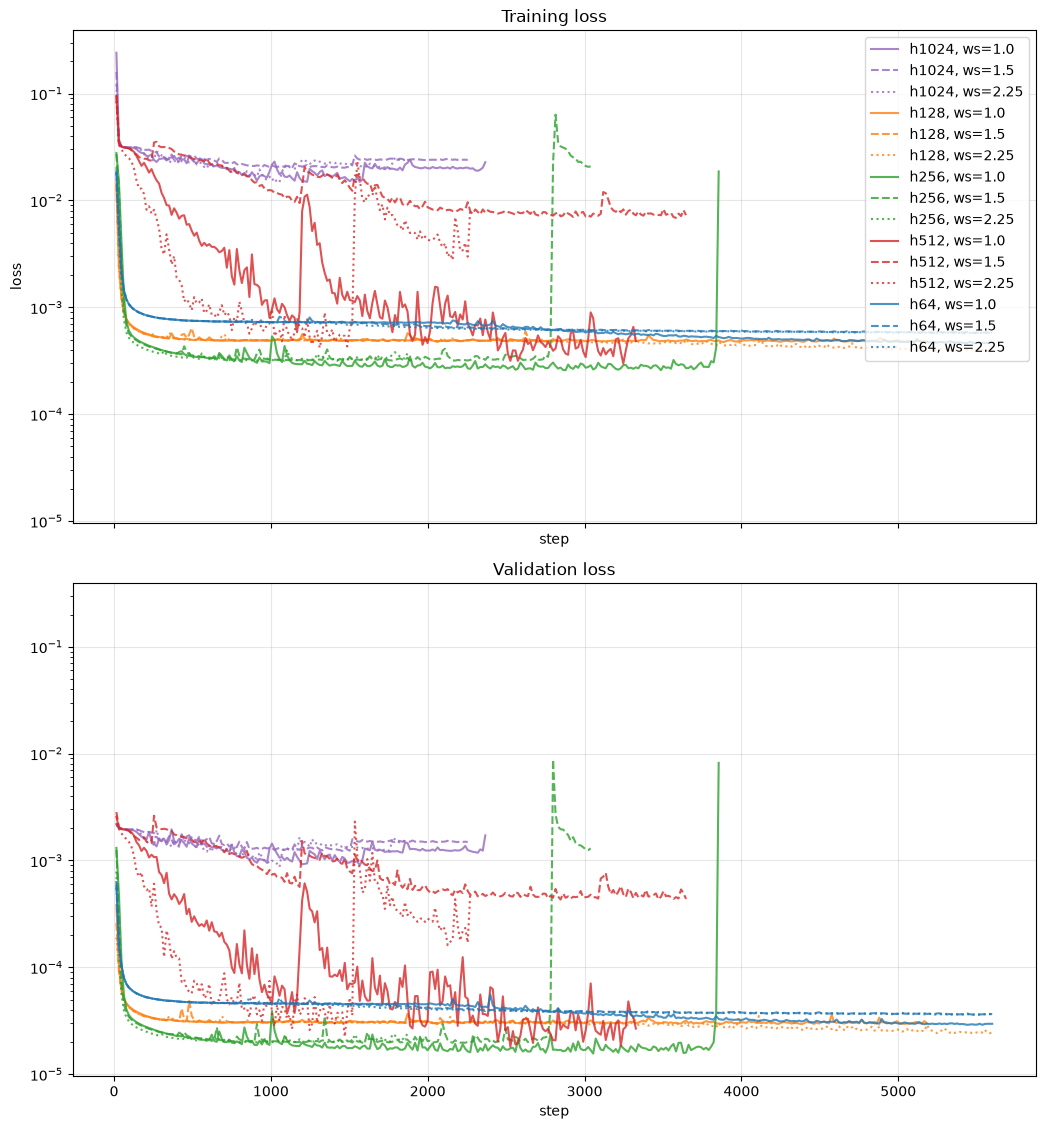

In [45]:
fig, axes = plt.subplots(2, 1, figsize=(12, 12), sharex=True, sharey=True)

for ax, tag, title in zip(
    axes,
    ["train/loss", "valid/loss"],
    ["Training loss", "Validation loss"],
):
    for run_dir in run_dirs:
        meta = parse_run_meta(run_dir.name)
        label = f"h{meta['hidden_size']}, ws={meta['ws']}"
        df = load_scalars(run_dir, tag)
        if not df.empty:
            ax.plot(
                df["step"],
                df["value"],
                color=colors[meta["hidden_size"]],
                linestyle=linestyles[meta["ws"]],
                label=label,
                alpha=0.8,
            )

    ax.set_yscale("log")
    ax.set_xlabel("step")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("loss")

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(fontsize=10)
# fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.02, 1), fontsize=8)

# fig.suptitle("Loss over steps for all runs", fontsize=14)
fig.tight_layout(rect=[0, 0, 0.88, 0.95])
plt.show()

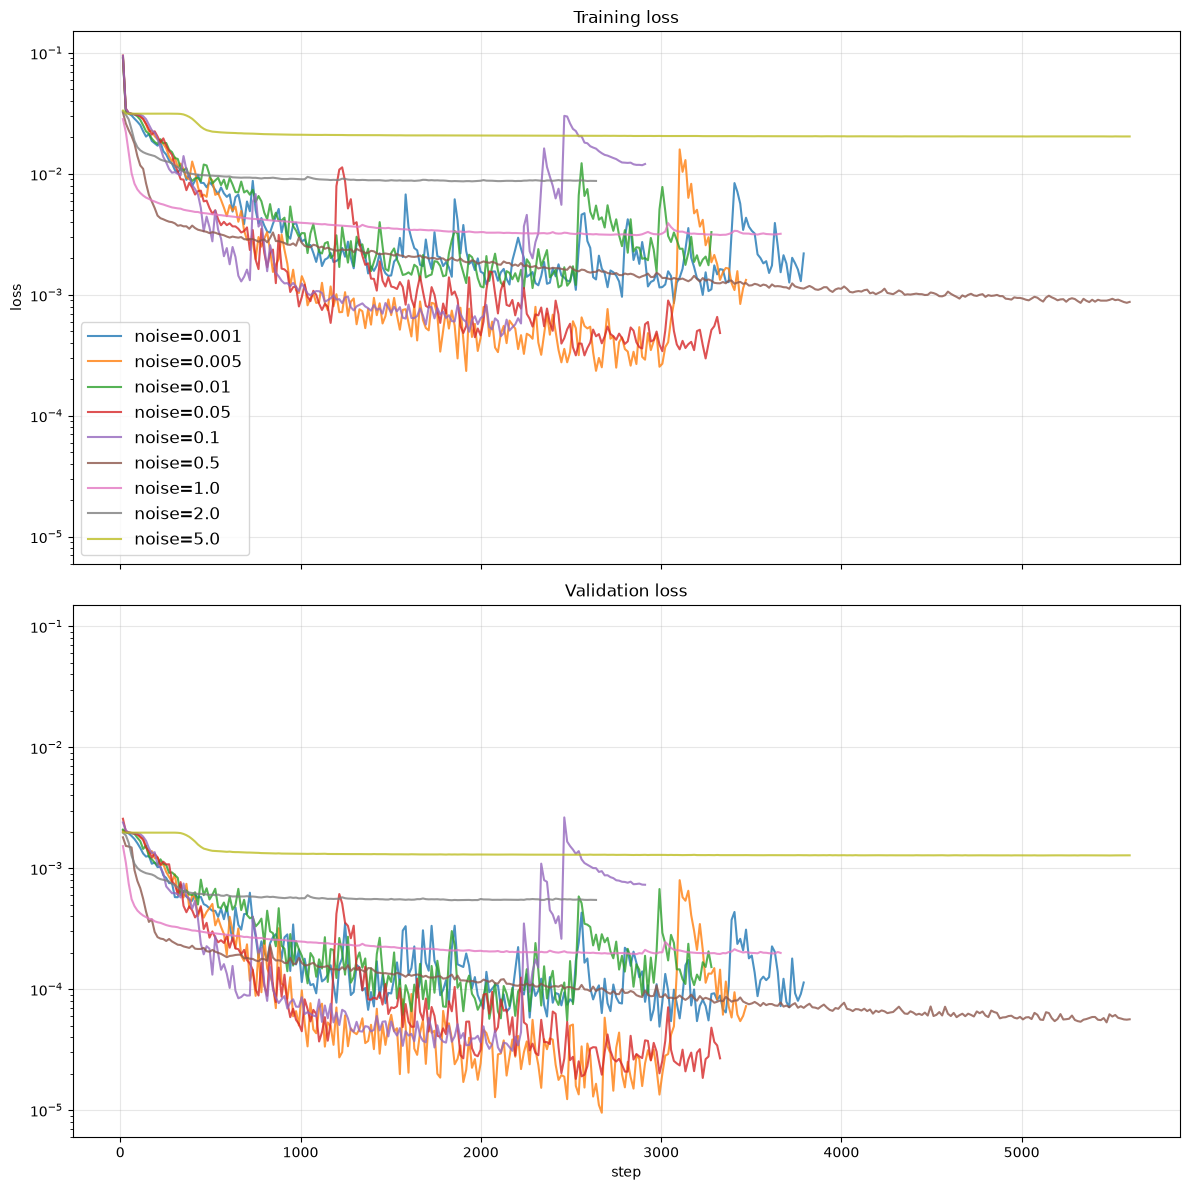

In [38]:
noise_base_dir = Path("..") / "runs" / "noise_runs"
noise_run_dirs = sorted(
    [p for p in noise_base_dir.iterdir() if p.is_dir()],
    key=lambda p: float(re.search(r"_n([\d.]+)_", p.name).group(1)),
)

def parse_noise_meta(run_name):
    return {"noise": float(re.search(r"_n([\d.]+)_", run_name).group(1))}

noise_levels = sorted({parse_noise_meta(p.name)["noise"] for p in noise_run_dirs})
noise_colors = {n: plt.cm.tab10(i) for i, n in enumerate(noise_levels)}

fig, axes = plt.subplots(2, 1, figsize=(12, 12), sharex=True, sharey=True)

for ax, tag, title in zip(
    axes,
    ["train/loss", "valid/loss"],
    ["Training loss", "Validation loss"],
):
    for run_dir in noise_run_dirs:
        meta = parse_noise_meta(run_dir.name)
        df = load_scalars(run_dir, tag)
        if not df.empty:
            ax.plot(
                df["step"],
                df["value"],
                color=noise_colors[meta["noise"]],
                label=f"noise={meta['noise']}",
                alpha=0.8,
            )

    ax.set_yscale("log")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("loss")
axes[1].set_xlabel("step")

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(fontsize=12)
fig.tight_layout()
plt.show()

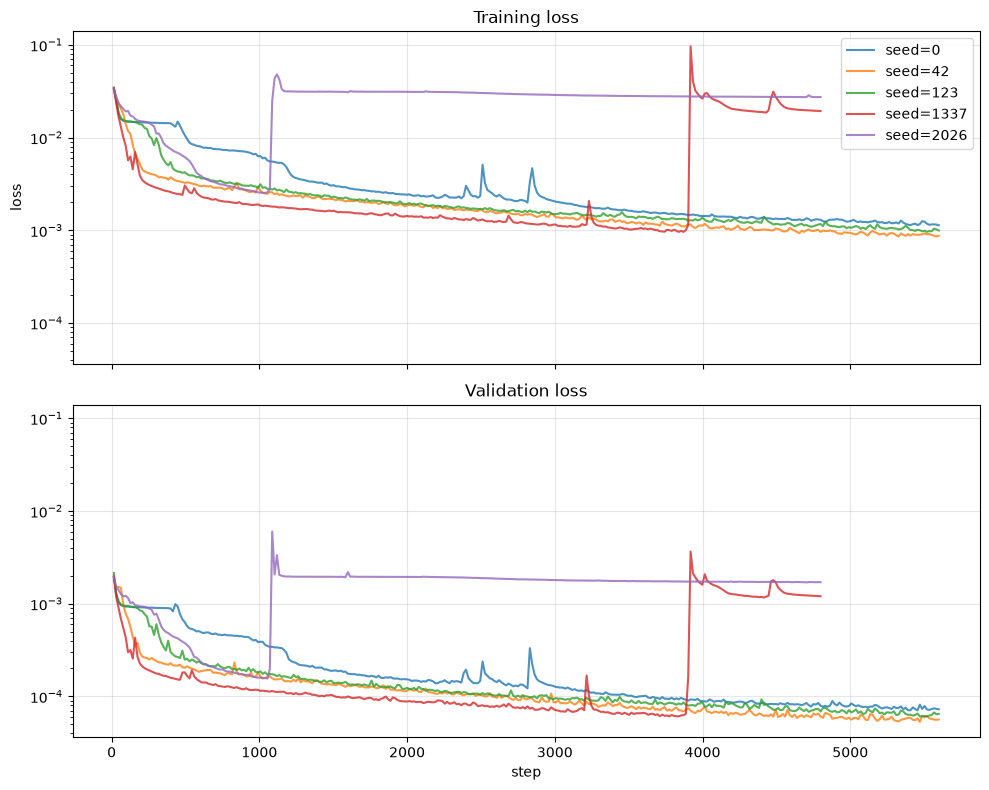

In [42]:
seed_base_dir = Path("..") / "runs" / "seed_runs"
seed_run_dirs = sorted(
    [p for p in seed_base_dir.iterdir() if p.is_dir()],
    key=lambda p: int(re.search(r"_s(\d+)_", p.name).group(1)),
)


def parse_seed_meta(run_name):
    return {"seed": int(re.search(r"_s(\d+)_", run_name).group(1))}


seeds = sorted({parse_seed_meta(p.name)["seed"] for p in seed_run_dirs})
seed_colors = {s: plt.cm.tab10(i) for i, s in enumerate(seeds)}

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, sharey=True)

for ax, tag, title in zip(
    axes,
    ["train/loss", "valid/loss"],
    ["Training loss", "Validation loss"],
):
    for run_dir in seed_run_dirs:
        meta = parse_seed_meta(run_dir.name)
        df = load_scalars(run_dir, tag)
        if not df.empty:
            ax.plot(
                df["step"],
                df["value"],
                color=seed_colors[meta["seed"]],
                label=f"seed={meta['seed']}",
                alpha=0.8,
            )

    ax.set_yscale("log")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("loss")
axes[1].set_xlabel("step")

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(fontsize=10)
fig.tight_layout()
plt.show()

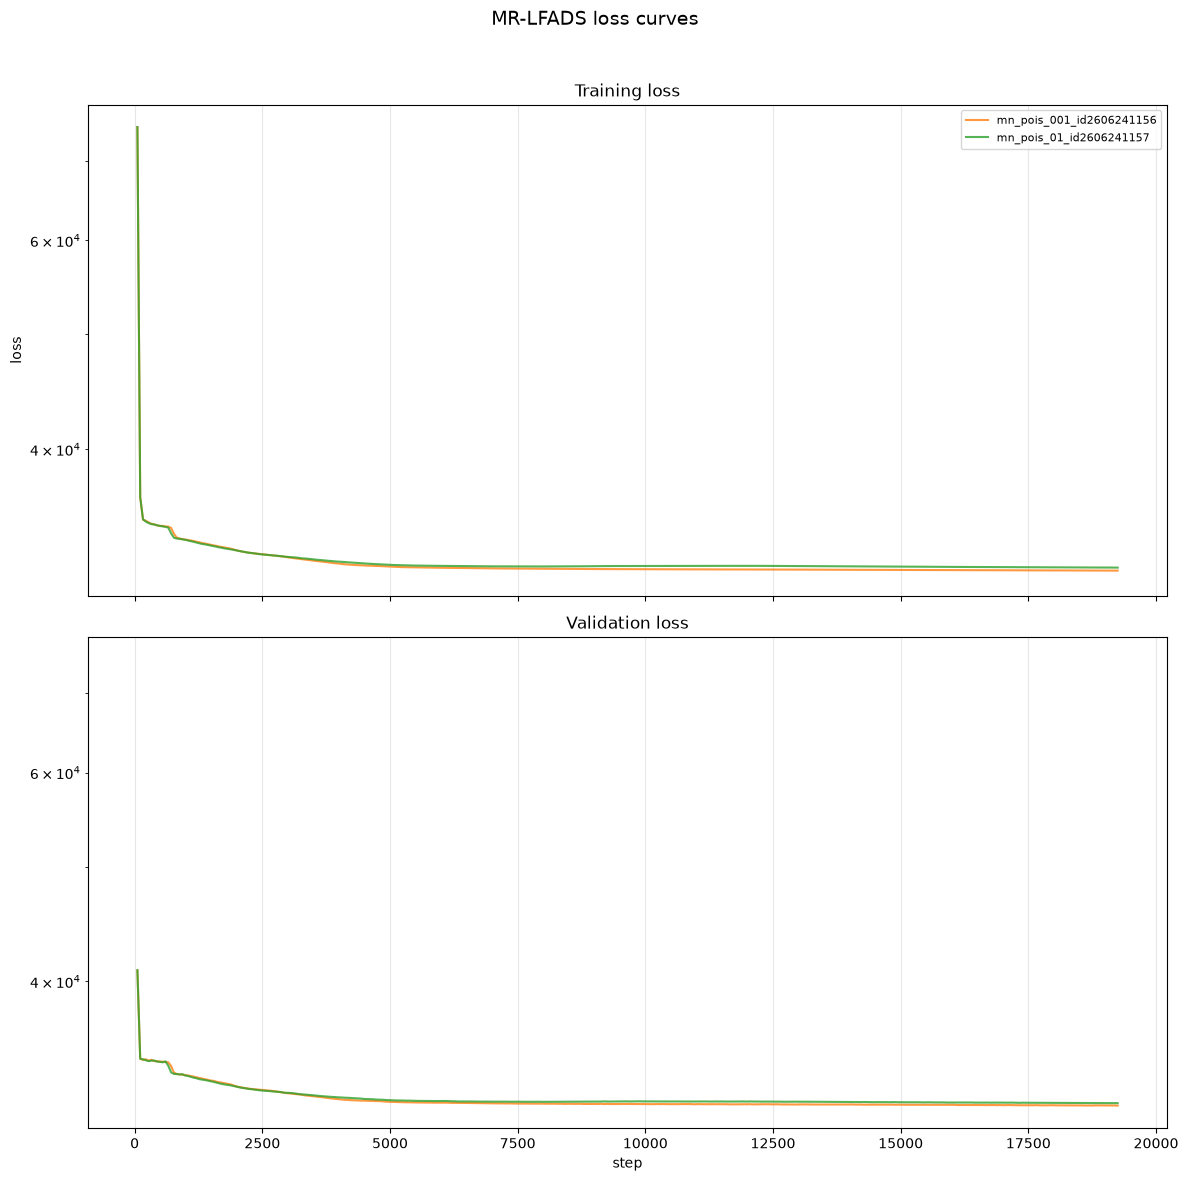

In [46]:
mrlfads_base_dir = Path("..") / "mrlfads-runs"
mrlfads_run_dirs = sorted([p for p in mrlfads_base_dir.iterdir() if p.is_dir()])
run_colors = {p.name: plt.cm.tab10(i) for i, p in enumerate(mrlfads_run_dirs)}

fig, axes = plt.subplots(2, 1, figsize=(12, 12), sharex=True, sharey=True)

for ax, tag, title in zip(
    axes,
    ["train/loss", "valid/loss"],
    ["Training loss", "Validation loss"],
):
    for run_dir in mrlfads_run_dirs:
        df = load_scalars(run_dir, tag)
        if df.empty:
            continue
        ax.plot(
            df["step"],
            df["value"],
            color=run_colors[run_dir.name],
            label=run_dir.name,
            alpha=0.8,
        )

    ax.set_yscale("log")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("loss")
axes[1].set_xlabel("step")

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(fontsize=8)
fig.suptitle("MR-LFADS loss curves", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()